Combining The Two Datasets 

In [ ]:
import pandas as pd

# 1. Load the datasets
df_true = pd.read_csv('True.csv')
df_fake = pd.read_csv('Fake.csv')

# 2. Add a 'label' column
df_true['label'] = 0
df_fake['label'] = 1

# 3. Merge (Concatenate) the two dataframes
df_merged = pd.concat([df_true, df_fake], axis=0)

# 4. Shuffle the data
df_merged = df_merged.sample(frac=1).reset_index(drop=True)

# 5. Quick look at the result
print(df_merged.head())
print(f"\nTotal rows: {len(df_merged)}")
print(f"Value counts:\n{df_merged['label'].value_counts()}")

                                               title  \
0   Trump’s ‘Spiritual Advisor’ Is Just Another C...   
1  With or without Democratic director, U.S. cons...   
2  CUBA STILL A COMMIE HELLHOLE AFTER OBAMA’S “NO...   
3  Pope, in change from predecessors, condemns nu...   
4  SOCIALIST MILLENNIAL MAGNET Bernie Sanders Tel...   

                                                text          subject  \
0  It seems that every time we turn around, there...             News   
1  WASHINGTON (Reuters) - Whether or not Richard ...     politicsNews   
2  Don t you know Obama would love to just throw ...  Government News   
3  VATICAN CITY (Reuters) - Pope Francis appeared...        worldnews   
4  Hillary Clinton s campaign also announced Sund...        left-news   

                  date  label  
0        July 11, 2016      1  
1  September 13, 2017       0  
2         Apr 13, 2015      1  
3   November 10, 2017       0  
4          Oct 3, 2016      1  

Total rows: 44898
Value counts:

In [ ]:
df_merged['full_content'] = df_merged['Merged Dataset'] + " " + df_merged['text']

Text Preprocessing

In [4]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download the required dictionary files
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize the tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Remove non-alphabetic characters (numbers and punctuation)
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    
    # 2. Lowercase all text
    text = text.lower()
    
    # 3. Tokenize (split into words)
    words = text.split()
    
    # 4. Remove Stopwords and Lemmatize
    # This turns "running" into "run" and removes "the", "a", etc.
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    # 5. Join words back into a single string
    return " ".join(cleaned_words)

# Apply it to your merged dataframe
print("Cleaning text... this might take a minute...")
df_merged['cleaned_content'] = df_merged['full_content'].apply(preprocess_text)

print("Check the difference:")
print(f"Original: {df_merged['full_content'].iloc[0][:100]}...")
print(f"Cleaned:  {df_merged['cleaned_content'].iloc[0][:100]}...")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...


Cleaning text... this might take a minute...
Check the difference:
Original:  Trump’s ‘Spiritual Advisor’ Is Just Another Con Artist And She Stole Her Con From Harry Potter It s...
Cleaned:  trump spiritual advisor another con artist stole con harry potter seems every time turn around new l...


Vectorization

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# 1. Split the data into Features (X) and Target (y)
# 'cleaned_content' is our text, 'label' is 0 (Real) or 1 (Fake)
X_text = df_merged['cleaned_content']
y = df_merged['label']

# 2. Split into Training and Testing sets (80% train, 20% test)
# This ensures we test the model on data it has NEVER seen before
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# 3. Initialize TF-IDF Vectorizer
# max_features=5000 limits the vocabulary to the top 5,000 most important words
tfidf = TfidfVectorizer(max_features=5000)

# 4. Transform the text into numbers
# We 'fit' on the training data only to avoid "cheating" (data leakage)
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

print(f"Training data shape: {X_train.shape}")
print("Vectorization complete! Your text is now a matrix of numbers.")

Training data shape: (35918, 5000)
Vectorization complete! Your text is now a matrix of numbers.


Model Training & Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

# 1. Initialize the Model
# 'max_iter' is set to 1000 to ensure the model has enough time to "converge" (find the best answer)
model = LogisticRegression(max_iter=1000)

# 2. Train the Model
print("Training the model... please wait...")
model.fit(X_train, y_train)

# 3. Make Predictions
y_pred = model.predict(X_test)

# 4. Evaluate the Results
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("-" * 30)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 30)

# Detailed report showing Precision and Recall
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

Training the model... please wait...
------------------------------
Accuracy: 0.9855
F1-Score: 0.9862
------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.99      0.98      4247
        Fake       0.99      0.98      0.99      4733

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



Bonus Step: Word Cloud Visualization

In [9]:
!pip install wordcloud

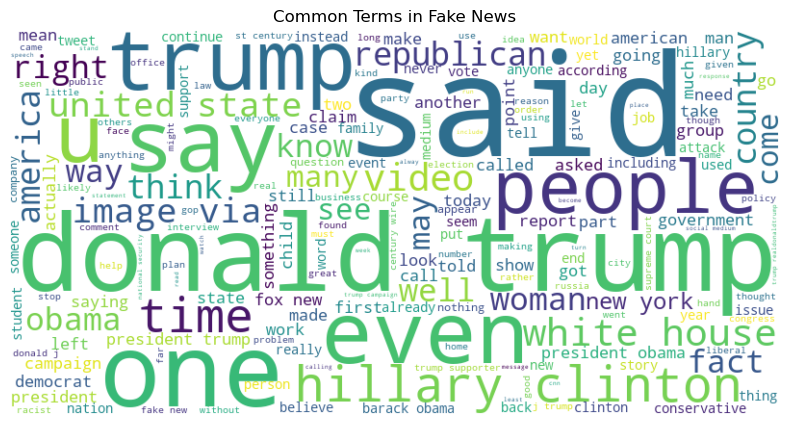

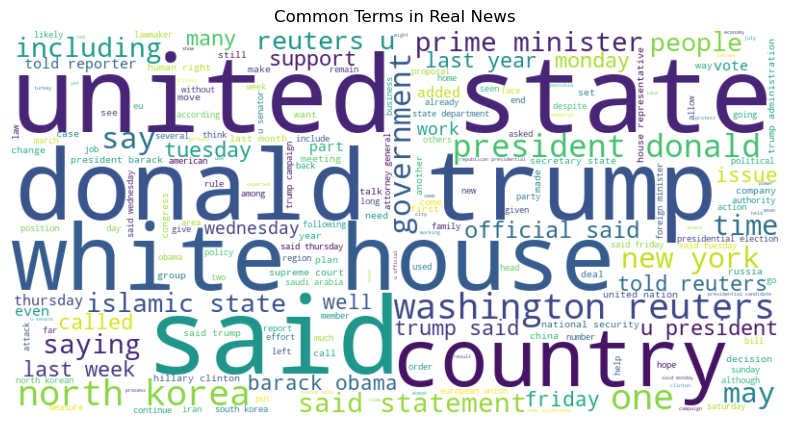

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Separate the text by label
fake_text = " ".join(df_merged[df_merged['label'] == 1]['cleaned_content'])
real_text = " ".join(df_merged[df_merged['label'] == 0]['cleaned_content'])

# 2. Function to plot the cloud
def plot_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

# 3. Generate both clouds
plot_cloud(fake_text, "Common Terms in Fake News")
plot_cloud(real_text, "Common Terms in Real News")